# AQT Calibration Drift — multi-year overlay

Overlays each year of a CROCUS AQT record on a common **Jan–Dec** axis to make
slow calibration drift visible. For each channel: a daily-mean line plus a
±1σ shaded band, one color per year.

The logic: real atmospheric variables (especially **pressure**) have little
genuine year-to-year trend, so a channel whose bands shift systematically from
year to year is showing **instrument drift**, not weather. Pressure is the
calibration canary — if its yearly bands separate, that licenses reading the
gas channels' shifts as drift too.

Built on the same QA/QC substrate as `resampled_aqt_quicklook`: data are
**hard-fault masked** (via `qaqc_inventory.build_flag_mask`) before overlaying,
so the bands reflect the drift of *good* data, not glitches. (Nonphysical
excursions like the pressure dives would otherwise wreck the mean and blow up
the σ band.)


## Imports

In [62]:
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import crocus_store as cs
from crocus_sites import NEIU, CSU, NU, UIC, ATMOS
import qaqc_inventory as q

importlib.reload(cs)
importlib.reload(q)


<module 'qaqc_inventory' from '/home/anderson/py/crocus/qaqc_inventory.py'>

## Configuration

`SITE` selects the node. Cleaned (hard-fault masked) data are used throughout.
Years are auto-detected from the record; NEIU's 2023 is partial (starts May),
which is fine — a partial year simply plots where it has data.


In [63]:
SITE = ATMOS
AQT_INSTRUMENT = "Vaisala AQT530"     # for titles; archive stores only class

ds = cs.load(SITE, 'aqt', outdir='data/sage_resampled')
mask = q.build_flag_mask(ds)

print('vars:', list(ds.data_vars))
print('span:', str(ds.time.values[0])[:10], '->', str(ds.time.values[-1])[:10])

# One distinct color per year (extend if more years appear).
YEAR_COLORS = {
    2023: "#1b9e77",   # teal-green
    2024: "#d95f02",   # orange
    2025: "#7570b3",   # purple
    2026: "#e7298a",   # magenta
}


vars: ['humidity', 'pressure', 'temp', 'co', 'no', 'no2', 'o3', 'pm1', 'pm10', 'pm25']
span: 2024-06-27 -> 2025-12-16


## Overlay helper

For one channel: mask hard-faults, take the 5-min mean series, and for each
calendar year compute a **daily mean** and **daily std**, indexed on a common
(month, day) axis so years align (a fake common non-leap year is used; Feb 29
is dropped so 2024 lines up with 2023/2025). Returns per-year daily frames.


In [64]:
# Dial this to control line smoothing. 1 = raw daily mean (noisy).
# Try 7 (weekly) or 30 (monthly) to see slow calibration drift emerge.
SMOOTH_DAYS = 7

# Common axis: map each timestamp to a fixed reference year so all years
# share an x-axis. Feb 29 is dropped so leap/non-leap years align.
REF_YEAR = 2001

# ppm floor for the electrochemical gas channels; at/below this is sensor
# floor, not real signal. Met channels don't get floored (None).
GAS_FLOOR = 0.001

def cleaned_mean(var, floor=None):
    """5-min mean series with hard-fault bins masked. If `floor` is given,
    values at/below it are also masked (electrochemical floor, not signal)."""
    da = ds[var].sel(statistic="mean")
    flag = var + "_badflag"
    series = da.where(~mask[flag]).to_series() if flag in mask else da.to_series()
    if floor is not None:
        series = series.where(series > floor)
    return series.dropna(), da.attrs.get("units", "")

def daily_stats_one_year(chunk):
    """Given one year's 5-min series, return a daily frame with a smoothed
    mean line and a daily standard-deviation band."""
    daily_mean = chunk.resample("1D").mean()
    daily_std = chunk.resample("1D").std()

    # Smooth only the center line, by SMOOTH_DAYS. The band stays on daily std.
    smooth_mean = daily_mean.rolling(SMOOTH_DAYS, min_periods=1, center=True).mean()

    frame = pd.DataFrame({"mean": smooth_mean, "std": daily_std})

    # Drop Feb 29, then remap the dates to the common reference year.
    frame = frame[~((frame.index.month == 2) & (frame.index.day == 29))]
    common_dates = pd.to_datetime({
        "year": REF_YEAR,
        "month": frame.index.month,
        "day": frame.index.day,
    })
    frame.index = common_dates.values
    return frame.sort_index()

def overlay_panel(ax, var, floor=None):
    series, units = cleaned_mean(var, floor=floor)
    for year in sorted(series.index.year.unique()):
        one_year = series[series.index.year == year]
        frame = daily_stats_one_year(one_year)
        color = YEAR_COLORS.get(year)
        m, s = frame["mean"], frame["std"]
        ax.plot(frame.index, m, lw=1.3, color=color, label=str(year))
        ax.fill_between(frame.index, m - s, m + s, color=color, alpha=0.12)
    # Fix the unit label: archive says ppb for gases but data is ppm.
    label_units = "ppm" if var in ("co", "no", "no2", "o3") else units
    ax.set_ylabel(f"{var}\n[{label_units}]")
    ax.grid(alpha=0.3)
    return label_units

## Meteorology: pressure, temperature, humidity

Pressure first — it's the drift control. Real annual-mean surface pressure
barely changes year to year, so separated pressure bands are almost certainly
the sensor. (In the quicklook, this channel shows nonphysical dives.)


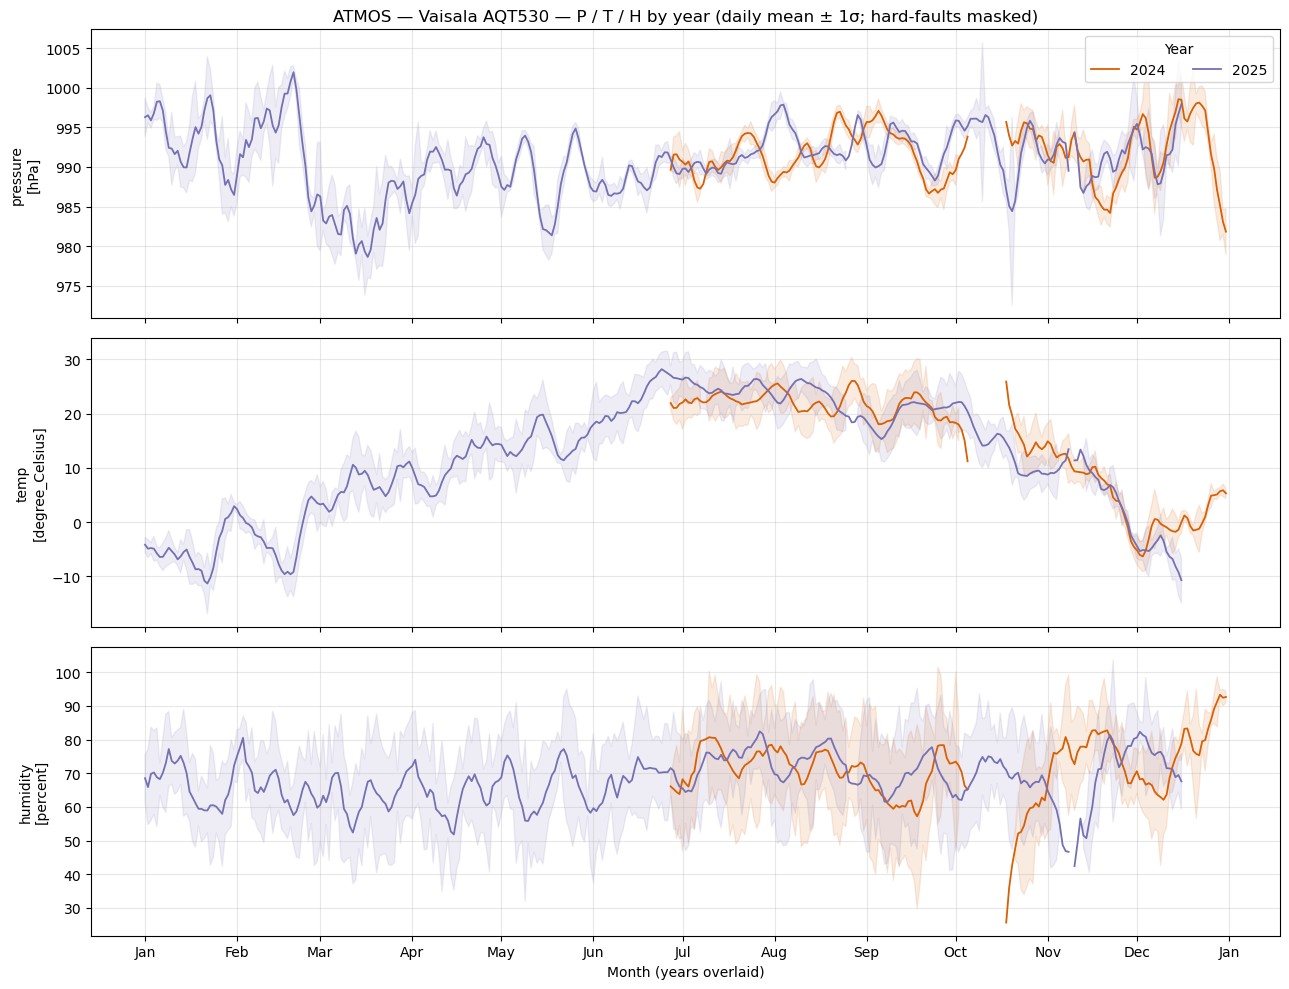

In [65]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, var in zip(axes, ['pressure', 'temp', 'humidity']):
    overlay_panel(ax, var)

# Month ticks on the shared common-year x-axis.
import matplotlib.dates as mdates
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].set_xlabel('Month (years overlaid)')

axes[0].legend(title='Year', loc='upper right', ncol=len(YEAR_COLORS))
axes[0].set_title(
    f'{SITE.abbr} — {AQT_INSTRUMENT} — P / T / H by year '
    '(daily mean ± 1σ; hard-faults masked)'
)
fig.tight_layout()
fig.savefig(f'figures/{SITE.abbr.lower()}_aqt_drift_met.png',
            dpi=200, bbox_inches='tight')
plt.show()


## Trace gases: CO, NO, NO₂, O₃

Read against the pressure panel above. If pressure bands are stable but a gas
channel's bands separate by year, that's a gas-specific calibration shift. If
*everything* (including pressure) drifts together, it points to a whole-sensor
issue. Ozone is the channel of prior concern (apparent spring-high/summer-low
seasonal shape).


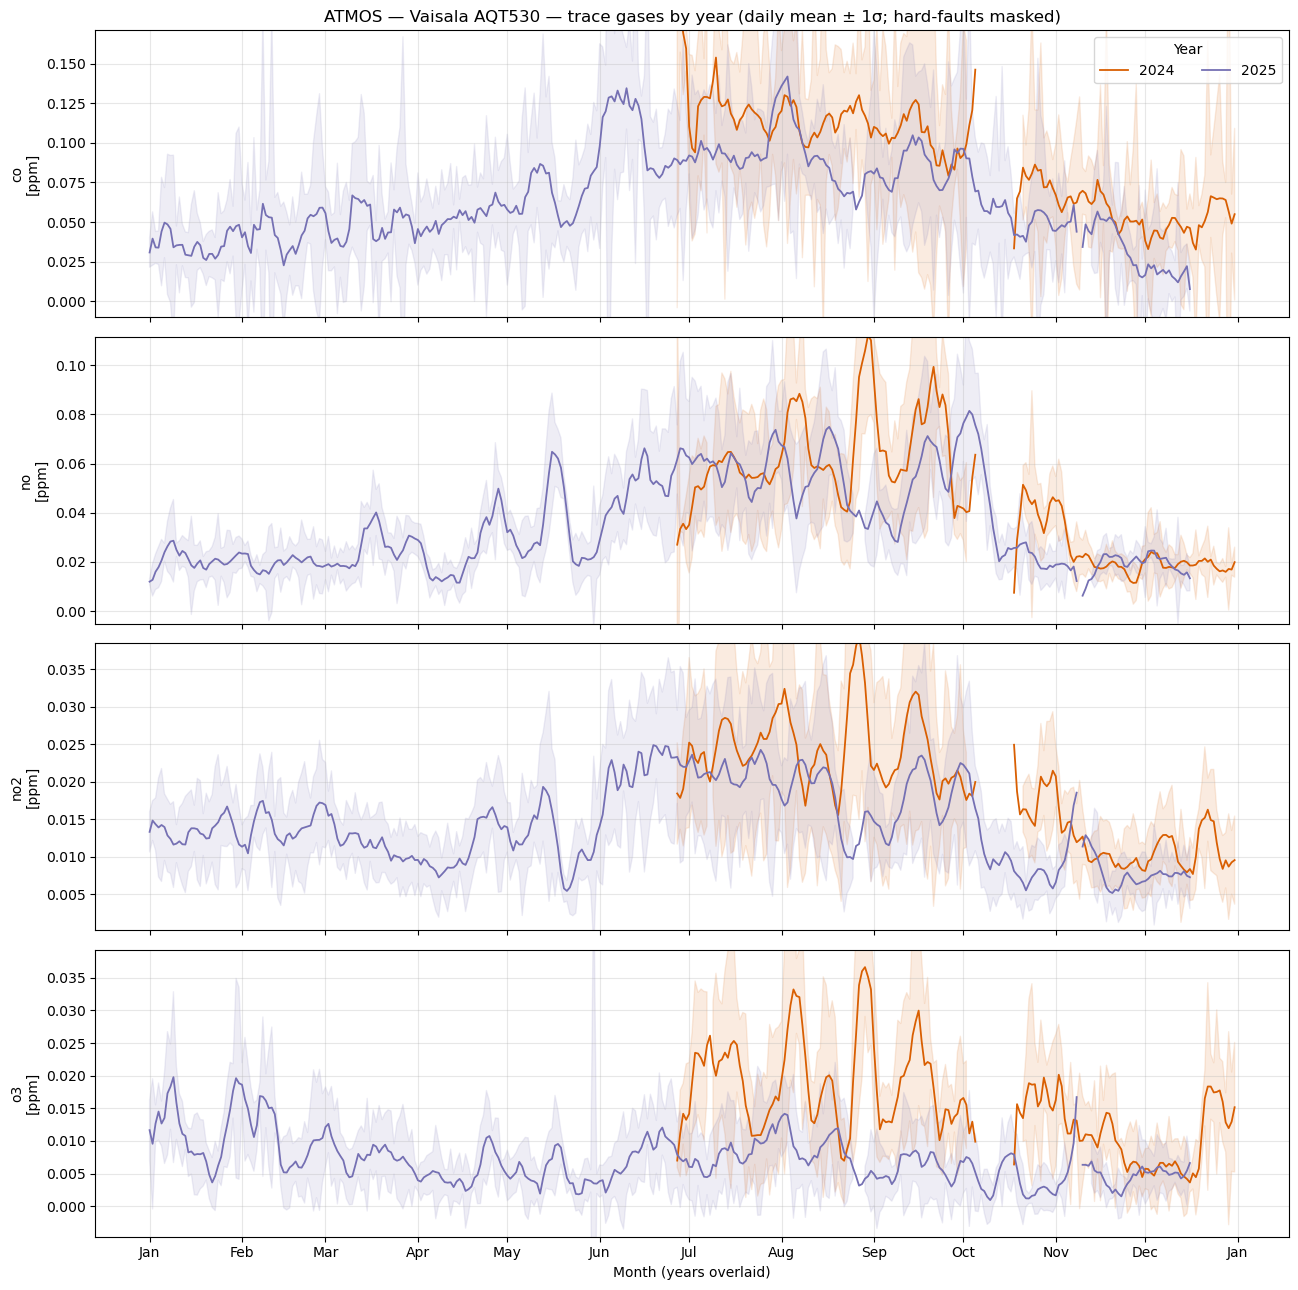

In [66]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)

for ax, var in zip(axes, ['co', 'no', 'no2', 'o3']):
    units = overlay_panel(ax, var)
    # Robust y-limits so a residual spike doesn't flatten the bands.
    lines = [ln.get_ydata() for ln in ax.get_lines()]
    allvals = np.concatenate(lines) if lines else np.array([np.nan])
    lo, hi = np.nanpercentile(allvals, [1, 99]) if np.isfinite(allvals).any() else (0, 1)
    if hi > lo:
        pad = (hi - lo) * 0.2
        ax.set_ylim(lo - pad, hi + pad)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].set_xlabel('Month (years overlaid)')

axes[0].legend(title='Year', loc='upper right', ncol=len(YEAR_COLORS))
axes[0].set_title(
    f'{SITE.abbr} — {AQT_INSTRUMENT} — trace gases by year '
    '(daily mean ± 1σ; hard-faults masked)'
)
fig.tight_layout()
fig.savefig(f'figures/{SITE.abbr.lower()}_aqt_drift_gases.png',
            dpi=200, bbox_inches='tight')
plt.show()


## Annual summary statistics

A compact table of per-year median and IQR for each channel — the numbers
behind the overlay. A drifting median across years is the quantitative version
of separated bands; a widening IQR is degrading precision (a different failure
mode from a shifting mean).


In [67]:
rows = []
for var in ['pressure', 'temp', 'humidity', 'co', 'no', 'no2', 'o3']:
    series, units = _cleaned_mean(var)
    series = series.dropna()
    for year, chunk in series.groupby(series.index.year):
        q25, q50, q75 = chunk.quantile([0.25, 0.50, 0.75])
        rows.append({
            'channel': var, 'units': units, 'year': int(year),
            'n': len(chunk), 'median': round(q50, 3),
            'IQR': round(q75 - q25, 3),
        })

drift_table = pd.DataFrame(rows)
from IPython.display import display
display(drift_table.pivot(index=['channel', 'units'], columns='year',
                          values='median'))
print("\nMedian by channel/year above; IQR (precision) in drift_table.")
ds.close()


,year,2024,2025
channel,units,,
co,ppm,0.075,0.053
humidity,percent,74.740,69.520
no,ppm,0.035,0.027
no2,ppm,0.016,0.013
o3,ppm,0.013,0.005
pressure,hPa,992.040,991.300
temp,degree_Celsius,17.340,12.660



Median by channel/year above; IQR (precision) in drift_table.


## Reading the plots

- **Pressure bands separate year to year** → sensor drift (pressure has no real
  interannual trend). This is the strongest single drift indicator.
- **A gas band shifts while pressure is stable** → that gas channel's
  calibration is drifting.
- **All channels drift together** → whole-sensor issue (power, siting, aging).
- **A band widens over years (bigger σ / IQR)** → degrading precision, distinct
  from a shifting mean.
- **Caveat:** apparent gas drift can still be real interannual atmospheric
  variability. Pressure anchors the interpretation; for ozone specifically, the
  AQT530-vs-QuantAQ intercomparison is the independent check.


In [68]:
COMMON_START = "05-05"   # latest year-start (2023 deployment)
COMMON_END = "12-16"     # earliest year-end (2025 truncation)
FLOOR = 0.001            # ppm; at/below this is sensor floor, not real ozone

o3 = ds["o3"].sel(statistic="mean").where(~mask["o3_badflag"]).to_series()

# Clean: floor-values (incl. negatives) -> NaN, so they don't drag the mean.
# (This MASKS them rather than clipping to zero; decide per the block/scatter
#  check whether that's right. Masking = "sensor wasn't measuring real ozone".)
o3_clean = o3.where(o3 > FLOOR)

rows = []
for yr in [2023, 2024, 2025]:
    y = o3_clean[o3_clean.index.year == yr]
    # restrict to the common calendar window
    md = y.index.strftime("%m-%d")
    y = y[(md >= COMMON_START) & (md <= COMMON_END)]
    monthly = y.resample("ME").mean()
    for ts, val in monthly.items():
        rows.append({"year": yr, "month": ts.month, "mean_o3": val})

import pandas as pd
comp = pd.DataFrame(rows).pivot(index="month", columns="year", values="mean_o3")
print("Monthly mean O3 (ppm), common window May 5 - Dec 16, floor-cleaned:")
print(comp.round(4))
print("\nMean over common window by year:")
print(comp.mean().round(4))

Monthly mean O3 (ppm), common window May 5 - Dec 16, floor-cleaned:
year     2024    2025
month                
5         NaN  0.0083
6      0.0175  0.0112
7      0.0225  0.0118
8      0.0288  0.0115
9      0.0214  0.0093
10     0.0216  0.0088
11     0.0148  0.0066
12     0.0088  0.0079

Mean over common window by year:
year
2024    0.0193
2025    0.0094
dtype: float64


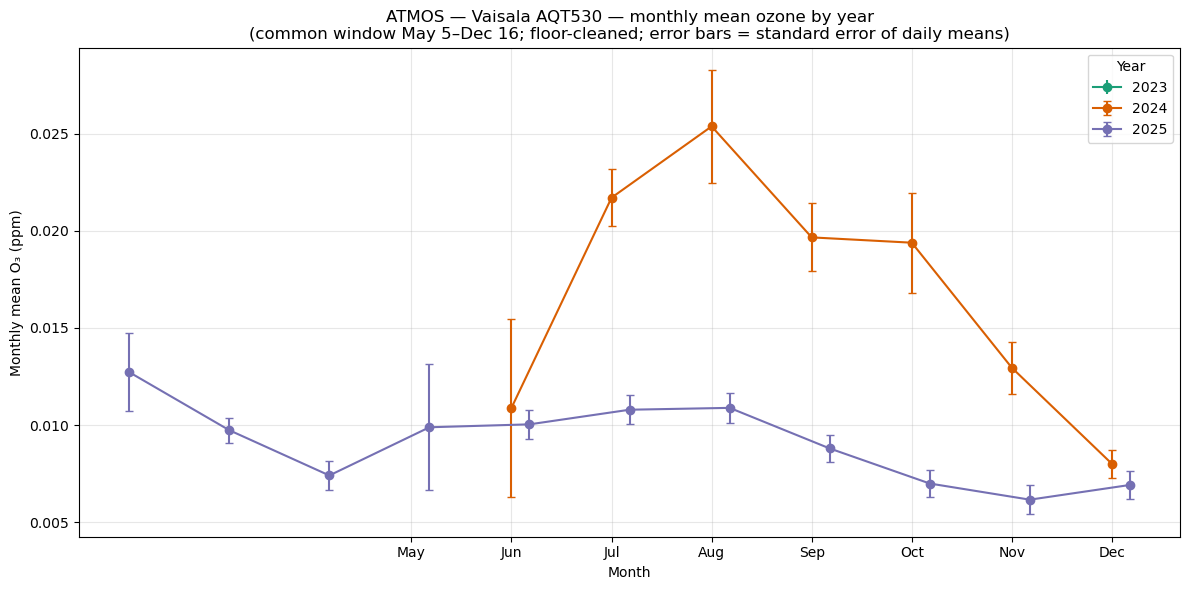

In [69]:
import matplotlib.pyplot as plt
import numpy as np

COMMON_START, COMMON_END = "02-05", "12-16"
FLOOR = 0.001

o3 = ds["o3"].sel(statistic="mean").where(~mask["o3_badflag"]).to_series()
o3_clean = o3.where(o3 > FLOOR)

fig, ax = plt.subplots(figsize=(12, 6))

# small horizontal offset per year so error bars don't overlap
offsets = {2023: -0.18, 2024: 0.0, 2025: 0.18}

for yr in [2023, 2024, 2025]:
    y = o3_clean[o3_clean.index.year == yr]
    md = y.index.strftime("%m-%d")
    y = y[(md >= COMMON_START) & (md <= COMMON_END)]

    # Daily means first (removes diurnal autocorrelation), then monthly stats
    # across days: mean and standard error = std(daily)/sqrt(n_days).
    daily = y.resample("1D").mean().dropna()
    g = daily.groupby(daily.index.month)
    monthly_mean = g.mean()
    monthly_sem = g.std() / np.sqrt(g.count())

    months = monthly_mean.index + offsets[yr]
    ax.errorbar(
        months, monthly_mean.values, yerr=monthly_sem.values,
        marker="o", markersize=6, capsize=3, lw=1.5,
        color=YEAR_COLORS[yr], label=str(yr),
    )

ax.set_xticks(range(5, 13))
ax.set_xticklabels(["May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_xlabel("Month")
ax.set_ylabel("Monthly mean O\u2083 (ppm)")
ax.set_title(
    f"{SITE.abbr} \u2014 {AQT_INSTRUMENT} \u2014 monthly mean ozone by year\n"
    "(common window May 5\u2013Dec 16; floor-cleaned; error bars = standard error of daily means)"
)
ax.legend(title="Year")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"figures/{SITE.abbr.lower()}_aqt_o3_monthly_by_year.png",
            dpi=200, bbox_inches="tight")
plt.show()